# 6. Imputación de datos faltantes en la serie de tiempo

Para la imputación de datos faltantes en las series de tiempo, se tomó como referencia la metodología propuesta en el artículo de Yamoa et al. (2020) llamado Missing data imputation of high-resolution temporal climate time series data, en el cual se evalúan diferentes enfoques para este propósito. Inicialmente, se implementó un modelo ARIMA con filtro de Kalman, el cual es ampliamente utilizado para la estimación de valores faltantes en series temporales. Sin embargo, debido a la presencia de brechas extensas en los datos, este enfoque presentó limitaciones, ya que dejó valores sin imputar y generó estimaciones que tendían a comportarse de forma similar a una interpolación lineal, sin capturar adecuadamente la dinámica de la serie. 

En consecuencia, se optó por emplear un modelo de regresión múltiple, el cual también mostró un buen desempeño en el estudio de referencia. No obstante, este método requiere que las variables predictoras estén completas, lo que representaba un inconveniente dado el alto porcentaje de datos faltantes en algunas estaciones. Para superar esta limitación, se calculó el promedio climatológico mensual de cada estación y se utilizó como una imputación temporal en las series predictoras únicamente para permitir la ejecución del modelo. Posteriormente, estos valores fueron removidos cuando cada estación era imputada como variable objetivo. Este procedimiento permitió completar de manera consistente las series de todas las estaciones, preservando en mayor medida la variabilidad temporal de los datos.

# 6.1. Preparación de los datos

In [9]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=['Fecha'], index_col='Fecha')

# El target cambia según la estación a la que se le vayan a imputar los datos
target = 'Barrancabermeja'

# Se definen las variables predictoras (estaciones)
predictors = [col for col in ['Calamar', 'Achi', 'ElBanco', 'SaladoBlanco', 'PuertoBerrio'] if col in df.columns]

print(f"Predictoras usadas: {predictors}")

# Se genera una copia del dataset original
df_original = df.copy()

Predictoras usadas: ['Calamar', 'Achi', 'ElBanco', 'SaladoBlanco', 'PuertoBerrio']


# 6.2. Simulación datos faltantes

In [10]:
# Se toma el dataset sin valores nulos 
df_valid = df.dropna()

# Simular faltantes (20%)
df_test = df_valid.copy()

np.random.seed(42)
mask = np.random.rand(len(df_test)) < 0.2

# Guardar valores reales antes de borrarlos
y_real = df_test.loc[mask, target].copy()
df_test.loc[mask, target] = np.nan

print(f"\nFilas totales: {len(df_test)} | Faltantes simulados: {mask.sum()} ({mask.mean()*100:.1f}%)")


Filas totales: 13614 | Faltantes simulados: 2762 (20.3%)


# 6.3. Entrenamiento modelo

In [11]:
# Se entrena el modelo con el 80% de los datos que no se han tocado
df_train = df_test[~mask][[target] + predictors].dropna()

X_train = sm.add_constant(df_train[predictors])
y_train = df_train[target]

model = sm.OLS(y_train, X_train).fit()

print("\n Modelo de validación")
print(model.summary())


 Modelo de validación
                            OLS Regression Results                            
Dep. Variable:        Barrancabermeja   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 1.274e+04
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:36:13   Log-Likelihood:                -53394.
No. Observations:               10852   AIC:                         1.068e+05
Df Residuals:                   10846   BIC:                         1.068e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -184.3348  

# 6.4. Evaluación del modelo

In [12]:
# Imputar los datos
X_mask = df_test.loc[mask, predictors].dropna(how='any')

if X_mask.empty:
    print("No hay filas con predictores completos para imputar.")
else:
    X_mask_const = sm.add_constant(X_mask, has_constant='add')
    y_pred_mask = model.predict(X_mask_const)

    df_test_imputed = df_test.copy()
    df_test_imputed.loc[X_mask.index, target] = y_pred_mask


# Se corren las métricas de validación
indices_eval   = X_mask.index
y_real_eval    = y_real.loc[indices_eval]
y_pred_eval    = df_test_imputed.loc[indices_eval, target]

rmse = np.sqrt(mean_squared_error(y_real_eval, y_pred_eval))
mae  = mean_absolute_error(y_real_eval, y_pred_eval)
r2   = r2_score(y_real_eval, y_pred_eval)

print("\n Métricas de validación")
print(f"Filas evaluadas : {len(indices_eval)} de {mask.sum()} simuladas")
print(f"RMSE            : {rmse:.3f}")
print(f"MAE             : {mae:.3f}")
print(f"R²              : {r2:.3f}")


 Métricas de validación
Filas evaluadas : 2762 de 2762 simuladas
RMSE            : 32.949
MAE             : 26.098
R²              : 0.860


# 6.5. Aplicación del modelo

In [13]:
df_train_final = df_valid[[target] + predictors].dropna()

X_train_final = sm.add_constant(df_train_final[predictors])
y_train_final = df_train_final[target]

model_final = sm.OLS(y_train_final, X_train_final).fit()

print("\n MODELO FINAL")
print(model_final.summary())

# Imputación final sobre datos reales
df_imputed    = df.copy()
missing_mask  = df_imputed[target].isna()

print(f"\nValores faltantes reales a imputar: {missing_mask.sum()}")

X_missing = df_imputed.loc[missing_mask, predictors].dropna(how='any')

if X_missing.empty:
    print("No hay filas con predictores completos para imputar en datos reales")
else:
    X_missing_const = sm.add_constant(X_missing, has_constant='add')
    pred_final      = model_final.predict(X_missing_const)
    df_imputed.loc[X_missing.index, target] = pred_final

    # Faltantes que no pudieron imputarse por falta de predictores
    sin_imputar = missing_mask.sum() - len(X_missing)
    if sin_imputar > 0:
        print(f"{sin_imputar} valores no pudieron imputarse por falta de predictores.")


# Se identifican los valores que fueron imputados y se añade la serie original como referencia

df_imputed[f'{target}_imputado_flag']  = 0
df_imputed.loc[missing_mask, f'{target}_imputado_flag'] = 1

df_imputed[f'{target}_original'] = df_original[target]

# Se exportan los datos a un archivo de Excel
output_path = "datos_imputados_barrancabermeja.xlsx"
df_imputed.to_excel(output_path)

print(f"\nArchivo guardado en: {output_path}")


 MODELO FINAL
                            OLS Regression Results                            
Dep. Variable:        Barrancabermeja   R-squared:                       0.856
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                 1.612e+04
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:36:20   Log-Likelihood:                -66965.
No. Observations:               13614   AIC:                         1.339e+05
Df Residuals:                   13608   BIC:                         1.340e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -186.0802      1.76

# 6.6. Visualización

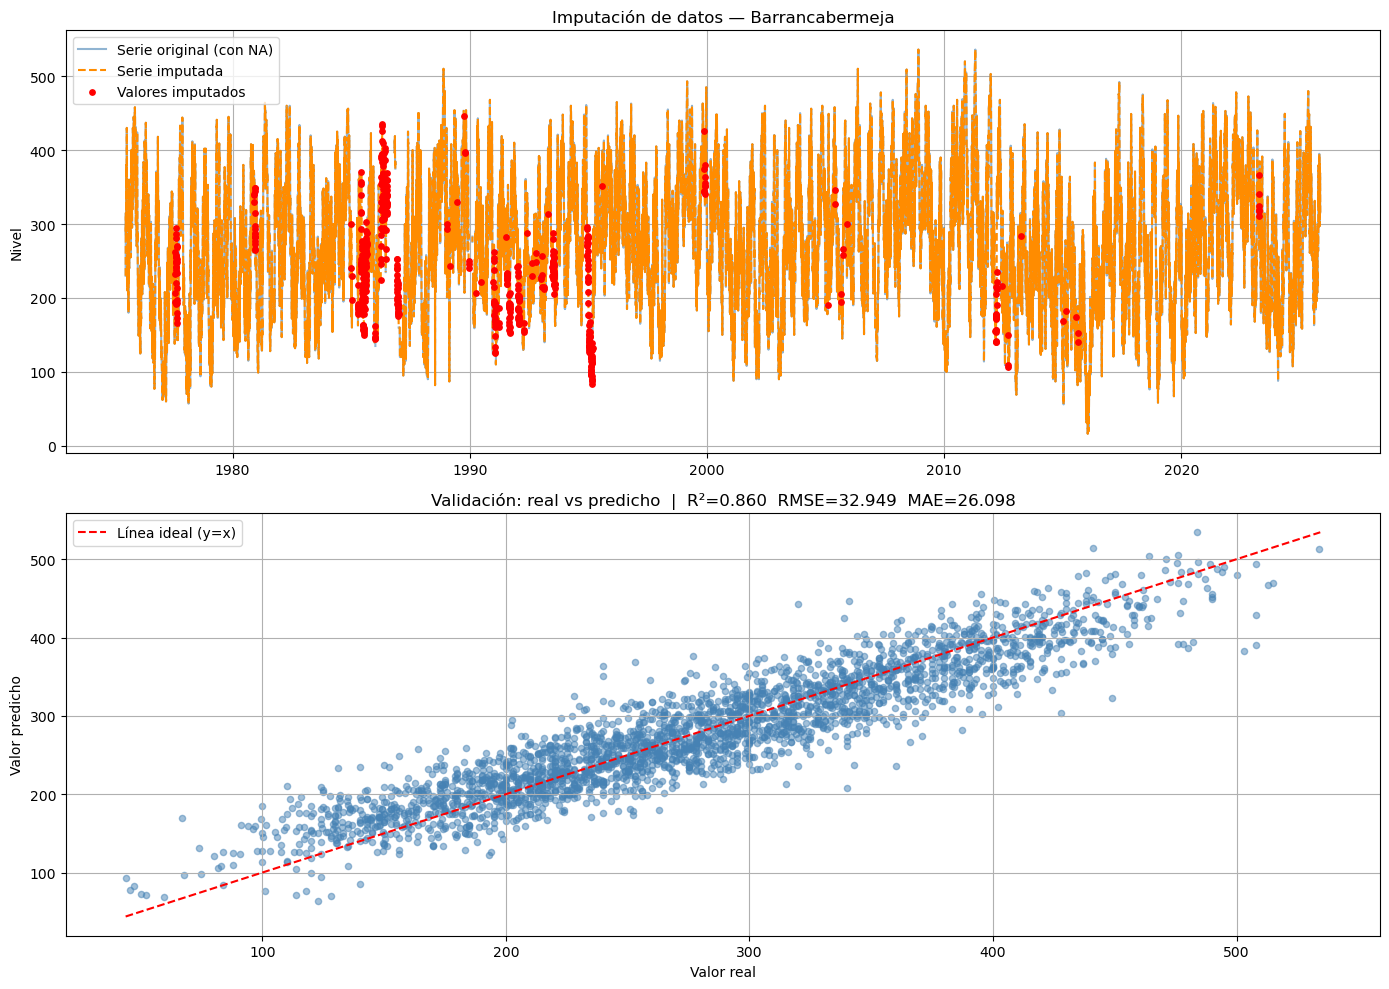

In [14]:
# Visualización de los datos
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Serie original vs imputada
ax1 = axes[0]
ax1.plot(df_original.index, df_original[target],
         label='Serie original (con NA)', alpha=0.6, color='steelblue')
ax1.plot(df_imputed.index, df_imputed[target],
         label='Serie imputada', linestyle='--', color='darkorange')
ax1.scatter(df_imputed.index[missing_mask],
            df_imputed.loc[missing_mask, target],
            color='red', s=15, label='Valores imputados', zorder=5)
ax1.set_title(f"Imputación de datos — {target}")
ax1.set_ylabel("Nivel")
ax1.legend()
ax1.grid(True)

# Valor real vs predicho (validación)
ax2 = axes[1]
ax2.scatter(y_real_eval, y_pred_eval, alpha=0.5, color='steelblue', s=20)
min_val = min(y_real_eval.min(), y_pred_eval.min())
max_val = max(y_real_eval.max(), y_pred_eval.max())
ax2.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', label='Línea ideal (y=x)')
ax2.set_title(f"Validación: real vs predicho  |  R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
ax2.set_xlabel("Valor real")
ax2.set_ylabel("Valor predicho")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
#plt.savefig("validacion_imputacion_barrancabermeja.png", dpi=150)
plt.show()
#print("Gráfica guardada en: validacion_imputacion_barrancabermeja.png")